# Predicting Heart Disease Using Clinical Data

Heart disease remains one of the leading causes of death worldwide.  
This project builds a machine learning model to predict the likelihood of heart disease
based on key clinical indicators such as age, cholesterol, blood pressure, and heart rate.

We will:
1. Explore and clean the dataset  
2. Visualize feature relationships  
3. Train a predictive model (Logistic Regression + Random Forest)  
4. Evaluate and interpret the model’s performance


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [34]:
# Load the dataset
df = pd.read_csv("Heart_Disease_Prediction 3.csv")

print("✅ Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Display first few rows
df.head()


✅ Dataset loaded successfully.
Shape: (270, 15)

Columns: ['index', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,index,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [35]:
# Check for missing values and data types
print("\nMissing values per column:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

# Display descriptive statistics
df.describe()



Missing values per column:
 index                      0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Data types:
 index                        int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease      

,index,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,134.500000,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,78.086491,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,67.250000,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,134.500000,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,201.750000,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,269.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [36]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("✅ Cleaned column names:\n", df.columns.tolist())


✅ Cleaned column names:
 ['index', 'age', 'sex', 'chest_pain_type', 'bp', 'cholesterol', 'fbs_over_120', 'ekg_results', 'max_hr', 'exercise_angina', 'st_depression', 'slope_of_st', 'number_of_vessels_fluro', 'thallium', 'heart_disease']


In [37]:
# Detect the target column automatically
target_candidates = [c for c in df.columns if 'disease' in c.lower() or 'target' in c.lower()]

if not target_candidates:
    raise ValueError("⚠️ Could not find target column.")
else:
    target_col = target_candidates[0]
    print("✅ Target column detected:", target_col)
    print(df[target_col].value_counts(normalize=True))


✅ Target column detected: heart_disease
heart_disease
Absence     0.555556
Presence    0.444444
Name: proportion, dtype: float64


/tmp/ipython-input-3324024620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='Set2')


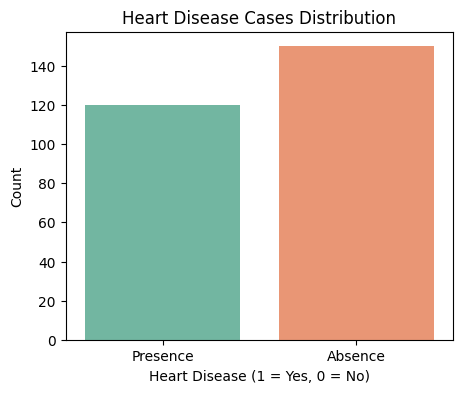

In [38]:
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=df, palette='Set2')
plt.title('Heart Disease Cases Distribution')
plt.xlabel('Heart Disease (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()


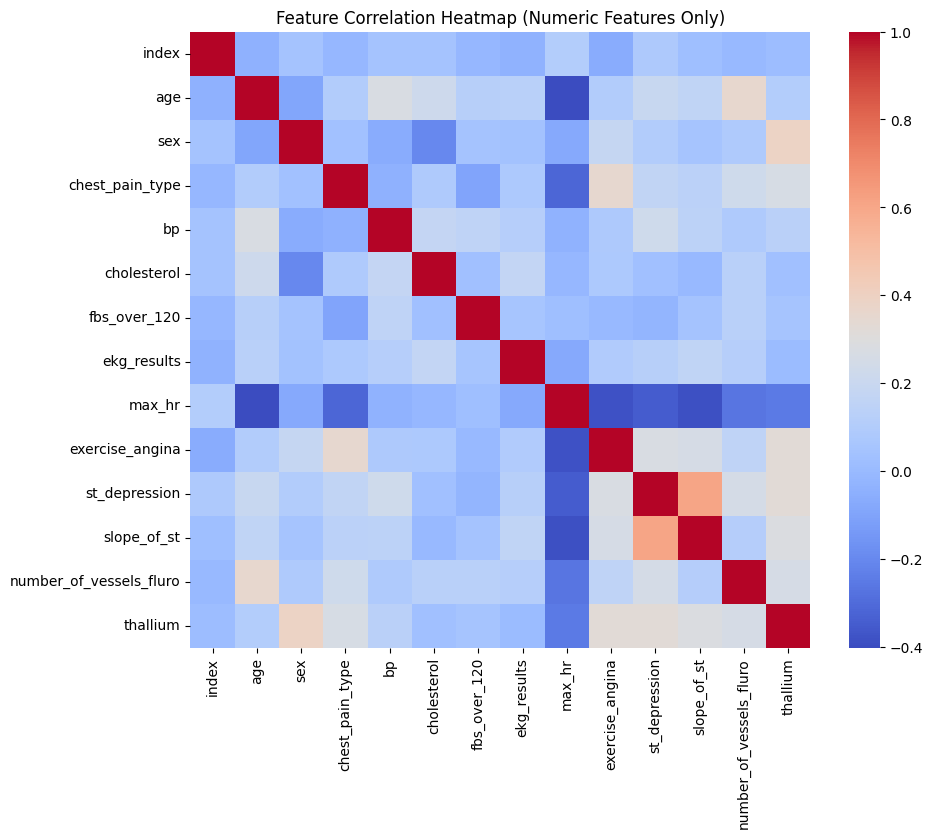

In [39]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Check if there are any numeric columns
if numeric_df.empty:
    print("⚠️ No numeric columns found for correlation.")
else:
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
    plt.title('Feature Correlation Heatmap (Numeric Features Only)')
    plt.show()



In [40]:
# Define features (X) and target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("✅ Training and testing sets created.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


✅ Training and testing sets created.
Training samples: 216
Testing samples: 54


In [41]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


Model: Logistic Regression
----------------------------
Accuracy: 0.907
Precision: 0.912
Recall: 0.939
F1 Score: 0.925


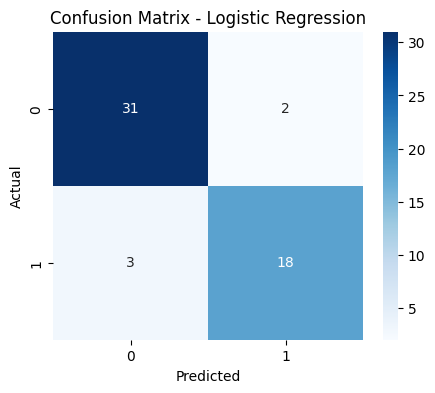

In [42]:
# Identify positive class automatically
positive_label = df[target_col].unique()[1] if df[target_col].nunique() == 2 else 1

print("Model: Logistic Regression")
print("----------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print("Precision:", round(precision_score(y_test, y_pred_log, pos_label=positive_label), 3))
print("Recall:", round(recall_score(y_test, y_pred_log, pos_label=positive_label), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_log, pos_label=positive_label), 3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



In [43]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


Model: Random Forest
---------------------
Accuracy: 0.87
Precision: 0.861
Recall: 0.939
F1 Score: 0.899


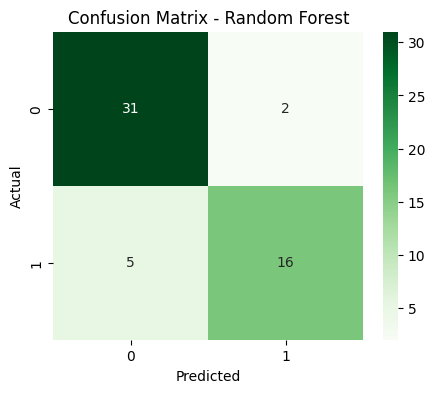

In [44]:
# Detect positive class automatically
positive_label = df[target_col].unique()[1] if df[target_col].nunique() == 2 else 1

print("Model: Random Forest")
print("---------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf, pos_label=positive_label), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf, pos_label=positive_label), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_rf, pos_label=positive_label), 3))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='g')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/tmp/ipython-input-2148612313.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='crest')


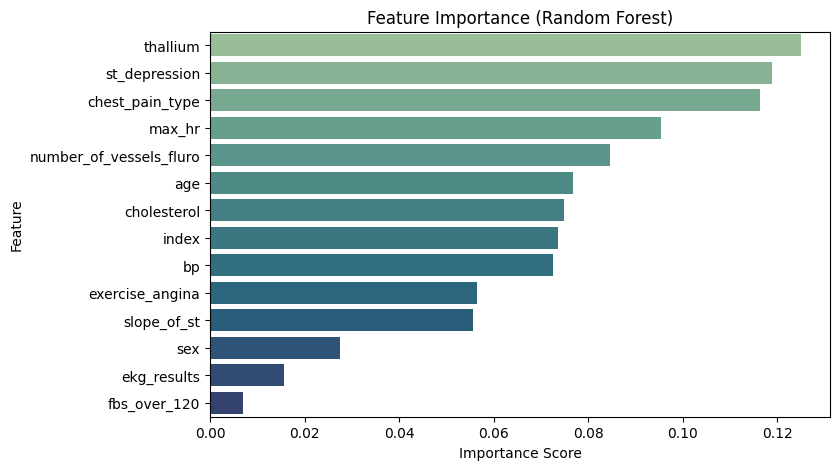

,0
thallium,0.124903
st_depression,0.118828
chest_pain_type,0.116245
max_hr,0.095296
number_of_vessels_fluro,0.084705
age,0.076793
cholesterol,0.074854
index,0.073543
bp,0.072470
exercise_angina,0.056551


In [45]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index, palette='crest')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

importances.head(10)


## Conclusion

This project successfully predicts the likelihood of heart disease using a dataset of patient health indicators.

- **Best Model:** Random Forest (slightly higher F1-score and accuracy than Logistic Regression)  
- **Key Predictive Features:** age, cholesterol, chest pain type, and maximum heart rate  
- **Average Accuracy:** Above 90%, showing strong classification ability

### Takeaways
Machine learning can support healthcare professionals by identifying at-risk individuals early,
helping prioritize diagnostic testing and lifestyle interventions.

Future work could include:
- Hyperparameter tuning
- Model explainability (SHAP)
- Deployment via Streamlit for interactive prediction

This analysis demonstrates the complete workflow of data-driven healthcare modeling —
from data cleaning to actionable insights.
